In [1]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt

In [2]:
metric_results = pd.read_csv('./keyWordLdaMataveTest/ldaMataveMetrics.csv')
human_results = pd.read_csv('./keyWordLdaMataveTest/dataGeneration/experimentTestNoteShuffle/sent/humanResults.csv')


In [3]:
metric_results

,model,CHI,ZIPF,CLASSIFIER,IRPR,FID,PR,DC,MAUVE,TRADITIONAL,ZERO
0,allTopicModels,0.000000,0.184044,0.967033,0.314002,0.759336,0.698251,0.932879,0.970704,0.510824,0.246050
1,LDA,0.000000,0.172124,0.951994,0.306521,0.726224,0.645994,0.915669,0.973749,0.504291,0.262112
2,MATAVE,0.000000,0.197774,0.983740,0.333860,0.837725,0.716517,0.941933,0.984797,0.518210,0.203755
3,realToReal,0.667949,0.027829,0.452498,0.193086,0.241809,0.117652,0.067015,0.030778,0.191097,0.091320
4,realToReal2,1.000000,0.047323,0.424715,0.189089,0.235171,0.112295,0.060020,0.015929,0.164203,0.113025
5,realToReal3,1.000000,0.012167,0.484539,0.190729,0.244031,0.127213,0.005042,0.021362,0.167957,0.098905


In [4]:
human_results

,Unnamed: 0,model,Accuracy,Precision,Recall,F1 Score,Cohen's Kappa
0,MATAVE,MATAVE,0.815315,0.891304,0.725664,0.800000,0.631766
1,LDA,LDA,0.927039,0.903226,0.957265,0.929461,0.854037
2,allTopicModels,allTopicModels,0.872527,0.898148,0.843478,0.869955,0.745196


In [5]:
# Get metric columns. 
metric_cols = [c for c in metric_results.columns if 'model' not in c]
# Extract real rows.
real_mask = metric_results['model'].str.startswith('real')
real_df = metric_results.loc[real_mask, metric_cols]

In [6]:
# Get mean and standard deviation. 
mean = real_df.mean()
std_dev = real_df.std(ddof=1)
# Avoid divide by zero.
std_dev = std_dev.replace(0, 1e-8)

# Calibrate scores. 
calibrated = metric_results.copy()

for m in metric_cols:
    calibrated[m] = ((metric_results[m] - mean[m]) / std_dev[m])

# Reliability is inverse variance. 
reliability = 1 / std_dev**2

weights = reliability / reliability.sum()

calibrated["final_score"] = (
    calibrated[metric_cols] * weights
).sum(axis=1)

calibrated["final_score_averaged"] = (
    calibrated[metric_cols] * weights
).mean(axis=1)

In [7]:
merged = human_results.merge(calibrated, on="model", how="inner")

In [8]:
merged

,Unnamed: 0,model,Accuracy,Precision,Recall,F1 Score,Cohen's Kappa,CHI,ZIPF,CLASSIFIER,IRPR,FID,PR,DC,MAUVE,TRADITIONAL,ZERO,final_score,final_score_averaged
0,MATAVE,MATAVE,0.815315,0.891304,0.725664,0.800000,0.631766,-4.638863,9.576593,17.697593,71.118714,129.593281,79.060469,26.454222,128.058145,23.603747,9.321105,79.354080,7.935408
1,LDA,LDA,0.927039,0.903226,0.957265,0.929461,0.854037,-4.638863,8.120213,16.637184,57.511520,105.404965,69.728416,25.680416,126.587675,22.648120,14.619101,65.953844,6.595384
2,allTopicModels,allTopicModels,0.872527,0.898148,0.843478,0.869955,0.745196,-4.638863,8.797018,17.139535,61.234975,112.588048,76.643388,26.187481,126.182384,23.096616,13.160923,69.881487,6.988149


In [9]:
for metric in metric_cols:
    print(metric)
    # Pearson is standardized and works best for linear relationships. 
    corr, p_value = pearsonr(
        merged[metric],
        merged["F1 Score"]
    )

    print("Pearson correlation:", corr)
    print("p-value:", p_value)

    # Spearman's does not need linearity, robust to outliers, no distributional assumptions (non normal distribution), versatile in variable types. 
    corr, p_value = spearmanr(
        merged[metric],
        merged["F1 Score"]
    )

    print("Spearman correlation:", corr)
    print("p-value:", p_value)

    # Kendall's Tau as there is a very small sample size. 
    tau, p_value = kendalltau(
        merged[metric],
        merged["F1 Score"]
    )

    print("Kendall's tau:", tau)
    print("p-value:", p_value)

CHI
Pearson correlation: nan
p-value: nan
Spearman correlation: nan
p-value: nan
Kendall's tau: nan
p-value: nan
ZIPF
Pearson correlation: -0.9999828885093421
p-value: 0.003724257168217035
Spearman correlation: -1.0
p-value: 0.0
Kendall's tau: -1.0
p-value: 0.3333333333333333
CLASSIFIER
Pearson correlation: -0.9998680038105171
p-value: 0.010343811438646044
Spearman correlation: -1.0
p-value: 0.0
Kendall's tau: -1.0
p-value: 0.3333333333333333
IRPR
Pearson correlation: -0.9782199558706073
p-value: 0.1331116022632568
Spearman correlation: -1.0
p-value: 0.0
Kendall's tau: -1.0
p-value: 0.3333333333333333
FID
Pearson correlation: -0.9831714407123014
p-value: 0.11695788954970064
Spearman correlation: -1.0
p-value: 0.0
Kendall's tau: -1.0
p-value: 0.3333333333333333
PR
Pearson correlation: -0.949870430365126
p-value: 0.20242925018549443
Spearman correlation: -1.0
p-value: 0.0
Kendall's tau: -1.0
p-value: 0.3333333333333333
DC
Pearson correlation: -0.9750180971656088
p-value: 0.14259889924296

/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_12907/410130545.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(
/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_12907/410130545.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(


In [10]:
# Pearson is standardized and works best for linear relationships. 
corr, p_value = pearsonr(
    merged["final_score_averaged"],
    merged["F1 Score"]
)

print("Pearson correlation:", corr)
print("p-value:", p_value)

# Spearman's does not need linearity, robust to outliers, no distributional assumptions (non normal distribution), versatile in variable types. 
corr, p_value = spearmanr(
    merged["final_score_averaged"],
    merged["F1 Score"]
)

print("Spearman correlation:", corr)
print("p-value:", p_value)

# Kendall's Tau as there is a very small sample size. 
tau, p_value = kendalltau(
    merged["final_score_averaged"],
    merged["F1 Score"]
)

print("Kendall's tau:", tau)
print("p-value:", p_value)

Pearson correlation: -0.9823911181776996
p-value: 0.11964660069186306
Spearman correlation: -1.0
p-value: 0.0
Kendall's tau: -1.0
p-value: 0.3333333333333333


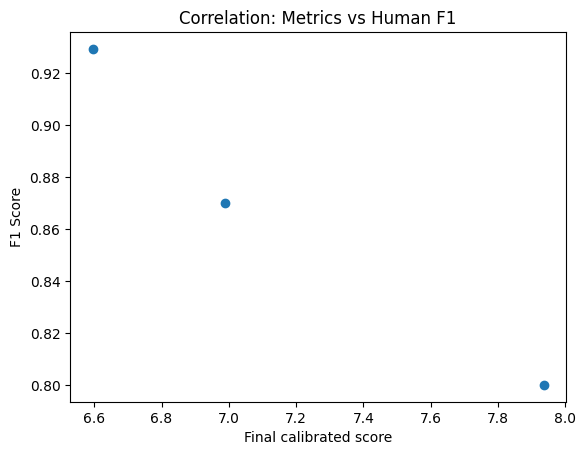

In [11]:
plt.scatter(
    merged["final_score_averaged"],
    merged["F1 Score"]
)

plt.xlabel("Final calibrated score")
plt.ylabel("F1 Score")
plt.title("Correlation: Metrics vs Human F1")
plt.show()